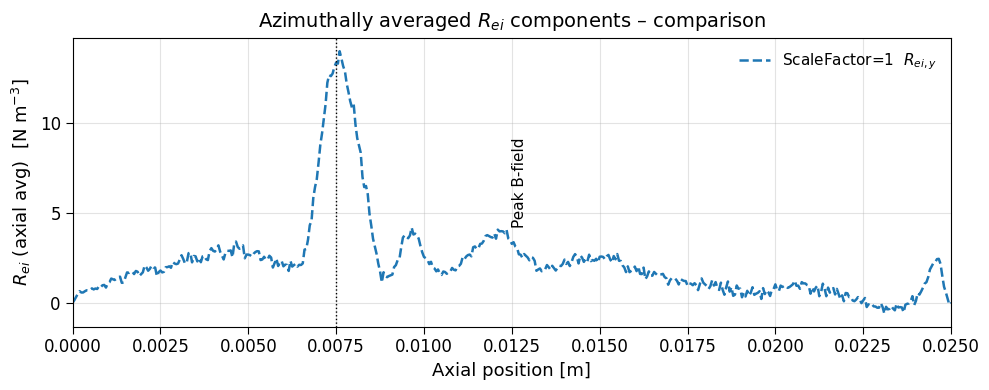

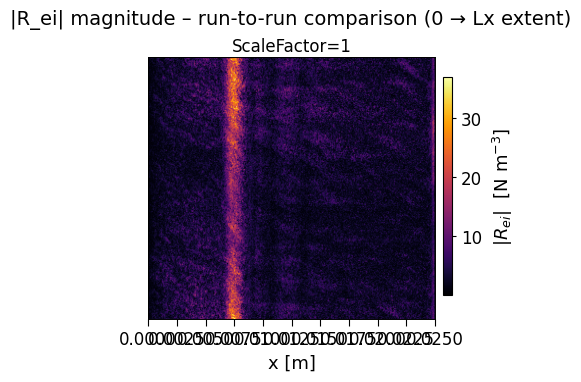

In [4]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

# ---------- CONFIG -----------------------------------------------------------
RUNS   = {
    "ScaleFactor=1": "out_0/500x256_7013140_2000000",
}
LAST_N     = 50
Lx_phys    = 0.025                    # [m]
q          = -1.602e-19              # [C]
PEAK_PERCENT = 30                    # Peak B-field (% of Lx)
# -----------------------------------------------------------------------------


# ---------- STYLE ------------------------------------------------------------
FS_TITLE = 14
FS_LABEL = 13
FS_LEG   = 11
FS_TICK  = 12
FS_CBARL = 13
FS_CBAR  = 12

def numeric_style(ax, nbins_x=10, nbins_y=5):
    ax.tick_params(axis='both', labelsize=FS_TICK, length=5)
    ax.locator_params(axis='x', nbins=nbins_x)
    ax.locator_params(axis='y', nbins=nbins_y)


# ---------- HELPERS ----------------------------------------------------------
def parse_nx_from_path(run_root: str):
    m = re.search(r'/(\d+)x(\d+)_', run_root.replace('\\', '/') + '/')
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None

def get_dx_for_run(run_root: str):
    nx, _ = parse_nx_from_path(run_root)
    if nx and nx > 0:
        return Lx_phys / nx
    ne_dir = os.path.join(run_root, "electronDensity")
    files = [f for f in os.listdir(ne_dir) if f.isdigit()]
    sample = np.loadtxt(os.path.join(ne_dir, sorted(files, key=int)[-1]))
    nx_guess = sample.shape[1]
    return Lx_phys / nx_guess

def load_run(run_root: str, dx_run: float):
    ne_dir, ex_dir, ey_dir = [os.path.join(run_root, d) for d in ("electronDensity", "Ex", "Ey")]
    files = sorted([f for f in os.listdir(ne_dir) if f.isdigit()], key=int)[-LAST_N:]
    ne  = np.stack([np.loadtxt(os.path.join(ne_dir, f)) for f in files])
    Ex  = np.stack([np.loadtxt(os.path.join(ex_dir, f)) for f in files])
    Ey  = np.stack([np.loadtxt(os.path.join(ey_dir, f)) for f in files])

    ne_mean, Ex_mean, Ey_mean = ne.mean(0), Ex.mean(0), Ey.mean(0)
    dne, dEx, dEy = ne - ne_mean, Ex - Ex_mean, Ey - Ey_mean

    Rei_x = q * np.mean(dne * dEx, axis=0)
    Rei_y = q * np.mean(dne * dEy, axis=0)
    Rei_mag = np.hypot(Rei_x, Rei_y)

    Rei_x_ax = Rei_x.mean(axis=0)
    Rei_y_ax = Rei_y.mean(axis=0)

    ny, nx = Rei_mag.shape
    x_m = np.arange(nx) * dx_run
    extent = [0.0, Lx_phys, 0.0, float(ny)]  # force same 0→Lx for all runs

    return {
        "Rei_x_ax": Rei_x_ax,
        "Rei_y_ax": Rei_y_ax,
        "Rei_mag":  Rei_mag,
        "x_m":      x_m,
        "extent":   extent,
        "nx":       nx,
        "ny":       ny,
    }


# ---------- LOAD ALL RUNS ----------------------------------------------------
data = {}
for label, folder in RUNS.items():
    dx_run = get_dx_for_run(folder)
    data[label] = load_run(folder, dx_run)


# ---------- 1) AXIAL-AVERAGE COMPARISON PLOT ---------------------------------
plt.figure(figsize=(10, 4))
colors = plt.cm.tab10(np.linspace(0, 1, len(RUNS)))
linestyles = ["--", ":", "-.", "-"]  # distinct line styles

for (label, dct), col, ls in zip(data.items(), colors, linestyles):
    plt.plot(dct["x_m"], dct["Rei_y_ax"],
             color=col, linestyle=ls, lw=1.8, label=f"{label}  $R_{{ei,y}}$")

x_peak_m = (PEAK_PERCENT / 100.0) * Lx_phys
plt.axvline(x_peak_m, color='black', ls=':', lw=1)
ylim = plt.gca().get_ylim()
plt.text(x_peak_m + 0.005, 0.5*(ylim[0]+ylim[1]), "Peak B-field",
         rotation=90, va="center", fontsize=FS_LEG)

plt.xlim(0, Lx_phys)
plt.xlabel("Axial position [m]", fontsize=FS_LABEL)
plt.ylabel(r"$R_{ei}$ (axial avg)  [N m$^{-3}$]", fontsize=FS_LABEL)
plt.title("Azimuthally averaged $R_{ei}$ components – comparison", fontsize=FS_TITLE, pad=8)
plt.grid(True, alpha=0.35)
plt.legend(ncol=2, fontsize=FS_LEG, frameon=False)
numeric_style(plt.gca(), nbins_x=10)
plt.tight_layout()
plt.show()


# ---------- 2) 2-D |R_ei| HEAT-MAPS ------------------------------------------
vmin = min(np.nanmin(d["Rei_mag"]) for d in data.values())
vmax = max(np.nanmax(d["Rei_mag"]) for d in data.values())

n_runs = len(RUNS)
fig, axes = plt.subplots(1, n_runs, figsize=(3.8*n_runs, 3.4), squeeze=False)
axes = axes[0]

for ax, (label, dct) in zip(axes, data.items()):
    im = ax.imshow(dct["Rei_mag"], origin='lower', cmap='inferno',
                   aspect='auto', extent=dct["extent"],
                   vmin=vmin, vmax=vmax)
    ax.set_xlim(0, Lx_phys)
    ax.set_title(label, fontsize=FS_LEG+1, pad=4)
    ax.set_xlabel("x [m]", fontsize=FS_LABEL)
    ax.set_yticks([])
    numeric_style(ax, nbins_x=10)
    for spine in ax.spines.values():
        spine.set_linewidth(0.7)

fig.subplots_adjust(right=0.88, wspace=0.18)
cbar_ax = fig.add_axes([0.90, 0.18, 0.025, 0.64])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r'$|R_{ei}|$  [N m$^{-3}$]', fontsize=FS_CBARL, labelpad=6)
cbar.ax.tick_params(labelsize=FS_CBAR, length=3)

fig.suptitle("|R_ei| magnitude – run-to-run comparison (0 → Lx extent)",
             fontsize=FS_TITLE, y=1.02)
plt.show()


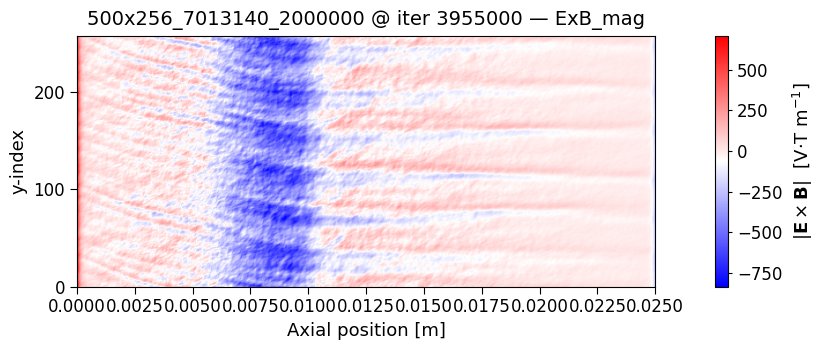

In [6]:
#!/usr/bin/env python3
import os
import re
import numpy as np
import matplotlib.pyplot as plt

# ================== USER INPUTS ==================
RUN_FOLDER   = "out_0/500x256_7013140_2000000"  # <-- change per run
ITERATION    = 3955000                                            # <-- pick snapshot
Lx_phys      = 0.025                                               # [m], device length
WHAT_TO_PLOT = "ExB_mag"   # "ExB_mag" or "vExB_mag" (drift speed |E×B|/B^2)
# =================================================

# ---------- STYLE (consistent with earlier) ----------
FS_TITLE = 14
FS_LABEL = 13
FS_TICK  = 12
FS_CBARL = 13
FS_CBAR  = 12

def numeric_style(ax, nbins_x=10, nbins_y=5):
    ax.tick_params(axis='both', labelsize=FS_TICK, length=5)
    ax.locator_params(axis='x', nbins=nbins_x)
    ax.locator_params(axis='y', nbins=nbins_y)

# ---------- HELPERS ----------
def parse_nx_from_path(run_root: str):
    """Parse nx, ny from path segment like '800x154_...'."""
    m = re.search(r'/(\d+)x(\d+)_', run_root.replace("\\", "/") + "/")
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None

def get_dx_for_run(run_root: str, Lx: float):
    nx, _ = parse_nx_from_path(run_root)
    if nx and nx > 0:
        return Lx / nx
    # Fallback: infer from a sample Ex file
    ex_dir = os.path.join(run_root, "Ex")
    files = [f for f in os.listdir(ex_dir) if f.isdigit()]
    if not files:
        raise RuntimeError(f"No numeric files in {ex_dir}")
    sample = np.loadtxt(os.path.join(ex_dir, sorted(files, key=int)[-1]))
    nx_guess = sample.shape[1]
    return Lx / nx_guess

def read_fields(run_root: str, iteration: int):
    """Load Ex, Ey arrays for a single iteration."""
    ex_path = os.path.join(run_root, "Ex", str(iteration))
    ey_path = os.path.join(run_root, "Ey", str(iteration))
    if not (os.path.isfile(ex_path) and os.path.isfile(ey_path)):
        raise FileNotFoundError(f"Missing Ex/Ey for iter {iteration} in {run_root}")
    Ex = np.loadtxt(ex_path)
    Ey = np.loadtxt(ey_path)
    if Ex.shape != Ey.shape:
        raise ValueError(f"Ex and Ey shapes differ: {Ex.shape} vs {Ey.shape}")
    return Ex, Ey  # shape [ny, nx]

def read_B_profile(run_root: str):
    """
    Read magneticField.out → (x_B, Bz). Expects columns [line_id, x, Bz].
    Uses line_id==0. x may be grid index or meters; we’ll align later.
    """
    bfile = os.path.join(run_root, "magneticField.out")
    if not os.path.isfile(bfile):
        raise FileNotFoundError(f"magneticField.out not found in {run_root}")
    arr = np.loadtxt(bfile, comments="#")
    if arr.ndim == 1:
        arr = arr[None, :]
    if arr.shape[1] < 3:
        raise ValueError("magneticField.out must have at least 3 columns: line_id, x, Bz")
    mask = (arr[:, 0] == 0)
    if not np.any(mask):
        raise RuntimeError("No line_id==0 in magneticField.out")
    x_B = arr[mask, 1].astype(float)
    Bz  = arr[mask, 2].astype(float)
    # sort by x
    order = np.argsort(x_B)
    return x_B[order], Bz[order]

# ---------- MAIN WORKFLOW ----------
run = RUN_FOLDER
iter_num = int(ITERATION)

# grids
dx = get_dx_for_run(run, Lx_phys)
Ex, Ey = read_fields(run, iter_num)
ny, nx = Ex.shape
x_m = np.arange(nx) * dx

# read B profile and align to x-grid
x_B, Bz_line = read_B_profile(run)

# If x_B looks like integer indices, convert to meters; else assume meters already
if np.allclose(x_B, np.round(x_B)):
    x_B_m = x_B * dx
else:
    x_B_m = x_B

# interpolate Bz(x) onto x_m and broadcast over y
Bz_on_x = np.interp(x_m, x_B_m, Bz_line, left=np.nan, right=np.nan)
# handle edges (optional: clamp to nearest valid B)
left_valid  = np.nanmin(np.where(np.isfinite(Bz_on_x), x_m, np.nan))
right_valid = np.nanmax(np.where(np.isfinite(Bz_on_x), x_m, np.nan))
if np.isnan(left_valid) or np.isnan(right_valid):
    raise RuntimeError("Bz profile does not overlap the simulation x-range.")
# simple edge fill
if np.isnan(Bz_on_x[0]):
    first = np.flatnonzero(np.isfinite(Bz_on_x))[0]
    Bz_on_x[:first] = Bz_on_x[first]
if np.isnan(Bz_on_x[-1]):
    last = np.flatnonzero(np.isfinite(Bz_on_x))[-1]
    Bz_on_x[last+1:] = Bz_on_x[last]

Bz = np.broadcast_to(Bz_on_x, (ny, nx))  # shape [ny, nx], positive ẑ by assumption

# ---------- E × B (with B = Bz ẑ) ----------
# E = (Ex, Ey, 0), B = (0, 0, Bz) → E×B = (Ey*Bz, -Ex*Bz, 0)
ExB_x = Ey * Bz
ExB_y = -Ex * Bz
ExB_mag = ExB_x + ExB_y   #np.hypot(ExB_x, ExB_y)

# Optional: E×B drift speed magnitude |v| = |E×B| / B^2 (avoid divide-by-zero)
eps = 1e-30
vExB_mag = ExB_mag / np.maximum(Bz**2, eps)

# Select what to plot
if WHAT_TO_PLOT.lower() == "vexb_mag":
    Z = vExB_mag
    zlabel = r"$|\mathbf{v}_{E\times B}|$  [m s$^{-1}$]"
else:
    Z = ExB_mag
    zlabel = r"$|\mathbf{E}\times\mathbf{B}|$  [V·T m$^{-1}$]"

# ---------- PLOT ----------
fig, ax = plt.subplots(figsize=(8.5, 3.6))
extent = [0.0, Lx_phys, 0.0, float(ny)]  # x in meters, y = index

im = ax.imshow(Z, origin="lower", cmap="bwr", aspect="auto",
               extent=extent)

# axis labels & cosmetics
ax.set_xlim(0, Lx_phys)
ax.set_xlabel("Axial position [m]", fontsize=FS_LABEL)
ax.set_ylabel("y-index", fontsize=FS_LABEL)
ax.set_title(f"{os.path.basename(run)} @ iter {iter_num} — {WHAT_TO_PLOT}", fontsize=FS_TITLE, pad=8)
numeric_style(ax, nbins_x=10, nbins_y=5)

# colorbar
cbar = fig.colorbar(im, ax=ax, pad=0.08)
cbar.set_label(zlabel, fontsize=FS_CBARL, labelpad=6)
cbar.ax.tick_params(labelsize=FS_CBAR, length=3)

plt.tight_layout()
plt.show()


Loading: out_0/500x256_7013140_2000000/Ex/3955000


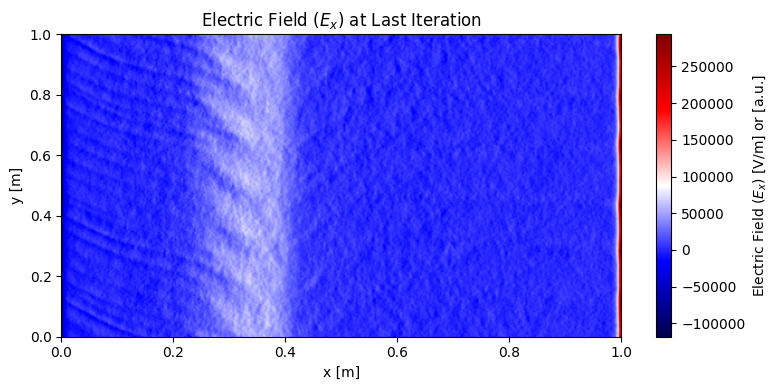

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import re

# === Directory containing data (assumed to be Ex) ===
base_dir = "out_0/500x256_7013140_2000000/Ex/"
file_pattern = os.path.join(base_dir, "*")

# Define a function to safely extract the numeric key
def get_iteration_key(f):
    """
    Searches for the first sequence of digits in the filename.
    Returns the integer if found.
    Returns -1 as an exception case if no number is found, 
    ensuring it sorts to the beginning.
    """
    try:
        match = re.search(r'\d+', os.path.basename(f))
        if match:
            return int(match.group())
        else:
            # Exception case: No digits found
            return -1
    except Exception:
        # Catch any other potential error during conversion/search
        return -1

# Get all files and sort them using the exception-handling key
files = sorted(glob.glob(file_pattern), key=get_iteration_key)

# Filter out the non-numeric files (which now have a key of -1) 
# and keep only the valid data files for subsequent steps.
valid_files = [f for f in files if get_iteration_key(f) != -1]

if not valid_files:
    raise FileNotFoundError("No valid numeric data files found in the directory.")

# === Load the last file (the one with the largest iteration number) ===
last_file = valid_files[-1]
print(f"Loading: {last_file}")
data = np.loadtxt(last_file)

# === Grid settings ===
# data.shape[0] gives the y-dimension size
grid_size_y = data.shape[0] 
# data.shape[1] gives the x-dimension size
grid_size_x = data.shape[1]

# Assuming 1m physical domain based on generic code, adjust if known
domain_length_x = 1.0 
domain_length_y = 1.0

x = np.linspace(0, domain_length_x, grid_size_x)
y = np.linspace(0, domain_length_y, grid_size_y)

# === Plot the 2D Electric Field (Ex) profile ===
plt.figure(figsize=(8, 4)) # Adjusted figure size for better aspect ratio

# --- Critical steps for zero-white plotting ---

# 1. Determine the maximum absolute value
# This sets symmetric color scaling around zero.
v_max = np.abs(data).max()
v_min = -v_max 

# 2. Use a diverging colormap ('seismic' or 'bwr')
im = plt.imshow(data, 
                origin='lower', 
                cmap='seismic', 
                aspect='auto', 
                #vmin=v_min, 
                #vmax=v_max,
                extent=[x.min(), x.max(), y.min(), y.max()])

# --- Plot Aesthetics ---
plt.title("Electric Field ($E_x$) at Last Iteration")
plt.xlabel("x [m]")
plt.ylabel("y [m]")

# Use the image object 'im' to create the colorbar
plt.colorbar(im, label="Electric Field ($E_x$) [V/m] or [a.u.]") 
plt.tight_layout()
plt.show()

In [10]:
#!/usr/bin/env python3
"""
Multi-folder Heat-map Movie Generator
-------------------------------------
For each folder name in TARGET_DIRS, it generates a corresponding MP4 animation.
"""

import os, glob, shutil, tempfile
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

# ========== USER CONFIGURATION ========== #
BASE_DIR     = "out_0/500x256_7013140_2000000/"
TARGET_DIRS  = ["electronDensity", "ionDensity","ionenergy","electronenergy","potential" ,"Ex", "Ey"]  # Add your folders here
FPS          = 5
CMAP         = "plasma"
DPI          = 150
DX_MICRONS   = 650            # in µm
DT_SEC       = 5e-12        # time step per file
# CLIM       = (0, 3e18)      # Uncomment and set if you want fixed color scale
# ======================================== #

for data_folder in TARGET_DIRS:
    DATA_DIR = os.path.join(BASE_DIR, data_folder)
    print(f"\n📂 Processing directory: {DATA_DIR}")

    all_entries = os.listdir(DATA_DIR)
    files = sorted(
        [
            os.path.join(DATA_DIR, f)
            for f in all_entries
            if os.path.isfile(os.path.join(DATA_DIR, f)) and "." not in f
        ],
        key=lambda f: int(os.path.basename(f))
    )

    if not files:
        print(f"⚠️  Skipped: No valid files in {DATA_DIR}")
        continue

    print(f"🔢 Found {len(files)} matrix files.")

    # Create temp PNG directory
    png_dir = tempfile.mkdtemp(prefix=f"frames_{data_folder}_")
    png_paths = []

    for idx, file_path in enumerate(files):
        matrix = np.loadtxt(file_path)
        fig, ax = plt.subplots(figsize=(8, 3), dpi=DPI)
        im = ax.imshow(matrix, origin='lower', cmap=CMAP, aspect="auto", extent=[0, 52, 0, 10])

        # Set color limits if needed
        # if CLIM:
        #     im.set_clim(*CLIM)
        # elif idx == 0:
        #     CLIM = im.get_clim()
        #     im.set_clim(*CLIM)

        raw_iter = int(os.path.basename(file_path))
        t_us = raw_iter * DT_SEC * 1e6
        ax.set_title(f"t = {t_us:.4f} µs", fontsize=10)
        ax.set_xlabel("Position X (cm)")
        ax.set_ylabel("Position Y (cm)")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        png_file = os.path.join(png_dir, f"frame_{idx:05d}.png")
        fig.savefig(png_file)
        png_paths.append(png_file)
        plt.close(fig)

    print(f"🖼️ Rendered {len(png_paths)} frames.")

    # Encode video
    movie_path = f"{data_folder}.mp4"
    print(f"🎞️  Encoding video → {movie_path} …")
    frames = [imageio.imread(p) for p in png_paths]
    imageio.mimsave(movie_path, frames, fps=FPS, codec="libx264")

    print(f"✅ Video saved: {movie_path}")

    # Cleanup PNGs
    shutil.rmtree(png_dir)



📂 Processing directory: out_0/500x256_7013140_2000000/electronDensity
🔢 Found 157 matrix files.
🖼️ Rendered 157 frames.
🎞️  Encoding video → electronDensity.mp4 …


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1200, 450) to (1200, 464) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


✅ Video saved: electronDensity.mp4

📂 Processing directory: out_0/500x256_7013140_2000000/ionDensity
🔢 Found 157 matrix files.
🖼️ Rendered 157 frames.
🎞️  Encoding video → ionDensity.mp4 …


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1200, 450) to (1200, 464) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


✅ Video saved: ionDensity.mp4

📂 Processing directory: out_0/500x256_7013140_2000000/ionenergy
🔢 Found 157 matrix files.
🖼️ Rendered 157 frames.
🎞️  Encoding video → ionenergy.mp4 …


...

✅ Video saved: potential.mp4

📂 Processing directory: out_0/500x256_7013140_2000000/Ex
🔢 Found 157 matrix files.
🖼️ Rendered 157 frames.
🎞️  Encoding video → Ex.mp4 …


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1200, 450) to (1200, 464) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


✅ Video saved: Ex.mp4

📂 Processing directory: out_0/500x256_7013140_2000000/Ey
🔢 Found 157 matrix files.
🖼️ Rendered 157 frames.
🎞️  Encoding video → Ey.mp4 …


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1200, 450) to (1200, 464) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


✅ Video saved: Ey.mp4


Loading: out/Ex/2000


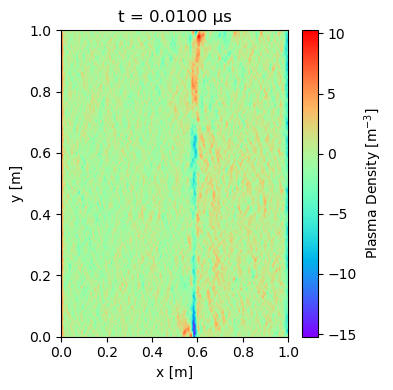

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import re

# === Directory containing ion density data ===
base_dir = "out/Ex/"
file_pattern = os.path.join(base_dir, "*")
files = sorted(glob.glob(file_pattern), key=lambda f: int(re.search(r'\d+', os.path.basename(f)).group()))

# === Load the last file ===
last_file = files[-1]
print(f"Loading: {last_file}")
data = np.loadtxt(last_file)

# === Grid settings ===
Ny, Nx = data.shape  # Ny = rows (y), Nx = columns (x)

Lx = 1   # domain length in x [m]
Ly = 1   # domain length in y [m]

dx = Lx / Nx
dy = Ly / Ny
DT_SEC = 5e-12

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)

# === Plot the 2D ion density profile ===
plt.figure(figsize=(4, 4))
plt.imshow(
    data,
    origin='lower',
    cmap='rainbow',
    aspect='auto',
    extent=[0, Lx, 0, Ly],   # [xmin, xmax, ymin, ymax] in meters
    #vmax=1e18
)
raw_iter = int(os.path.basename(last_file))
t_us = raw_iter * DT_SEC * 1e6
plt.title(f"t = {t_us:.4f} µs")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.colorbar(label="Plasma Density [m$^{-3}$]")
plt.tight_layout()
plt.show()
